<!-- Thêm thuộc tính để xuất ra html output không bị quá dài -->
<script>
window.addEventListener("load", function() {
  // Lấy tất cả các ô output có thể
  const outputs = document.querySelectorAll(
    '.jp-OutputArea-output, .output_area, .output_subarea'
  );

  outputs.forEach(function(output) {
    // Tính số dòng (dựa trên text)
    const text = output.innerText || "";
    const lineCount = text.split("\n").length;

    if (lineCount > 50) {
      const wrapper = document.createElement("div");
      wrapper.style.maxHeight = "300px";
      wrapper.style.overflowY = "auto";
      wrapper.style.border = "1px solid #ccc";
      wrapper.style.borderRadius = "6px";
      wrapper.style.padding = "4px";
      wrapper.style.background = "#f9f9f9";
      wrapper.title = `Collapsed: ${lineCount} lines`;

      // Di chuyển output vào wrapper
      output.parentNode.insertBefore(wrapper, output);
      wrapper.appendChild(output);
    }
  });
});
</script>

# Popularity Prediction
- Full name: Luu Vinh Tuong
- Student code: 22133064

This notebook is dedicated to predicting the popularity of songs based on various audio features using machine learning models. The main goal is to answer the question: Which factors in music have the strongest influence on the popularity and ranking of a song?

# I. Required Libraries

In [1]:
import findspark
findspark.init()
import pyspark
findspark.find()
from pyspark.sql import SparkSession
from pyspark.sql.functions import count
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, TrainValidationSplit
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.sql.functions import udf
from pyspark.ml.linalg import VectorUDT
from pyspark.ml.regression import RandomForestRegressor
from xgboost.spark import SparkXGBRegressor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# II. Data Preprocessing & Visualization

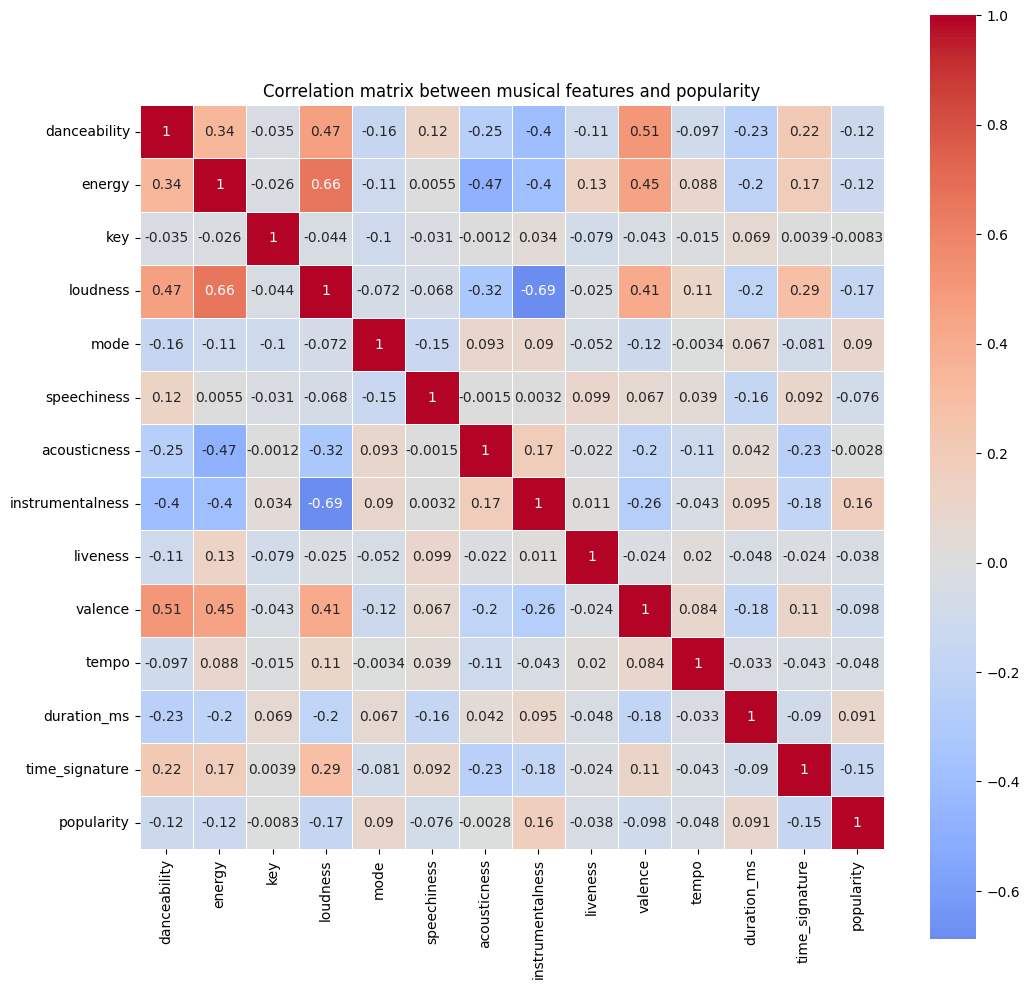

In [2]:
# Correlation matrix between musical features and popularity
df = pd.read_csv('/opt/workspace/Final_project/data/2025_spotify_songs.csv')

correlation_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms','time_signature', 'popularity']


correlation_matrix = df[correlation_features].corr()

plt.figure(figsize=(12, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation matrix between musical features and popularity')
plt.show()

## Remarks:
- The correlation matrix between input variables and popularity is very low.
- It is expected that the regression coefficients will have poor values, and the model cannot show substantial differences between the songs.

# III. Experimenting with Models

## A. Initializing Spark Program and Dataset


### 1. Initializing Spark Program

In [ ]:
spark = (
    SparkSession.builder
    .appName("SpotifyPopularityAnalysis")
    .master("spark://spark-master:7077")
    .config("spark.driver.host", "jupyter-pyspark")
    .config("spark.driver.memory", "4g")          
    .config("spark.executor.memory", "6g")         
    .config("spark.executor.cores", "4")
    .config("spark.sql.shuffle.partitions", "50")  
    .config("spark.default.parallelism", "50")
    .config("spark.sql.files.maxPartitionBytes", "64m") 
    .config("spark.rpc.message.maxSize", "512")
    .config("spark.network.timeout", "600s")
    .getOrCreate()
)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/20 14:04:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 33374)
Traceback (most recent call last):
  File "/opt/bitnami/python/lib/python3.12/socketserver.py", line 318, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/opt/bitnami/python/lib/python3.12/socketserver.py", line 349, in process_request
    self.finish_request(request, client_address)
  File "/opt/bitnami/python/lib/python3.12/socketserver.py", line 362, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/opt/bitnami/python/lib/python3.12/socketserver.py", line 761, in __init__
    self.handle()
  File "/opt/bitnami/spark/python/pyspark/accumulators.py", line 295, in handle
    poll(accum_updates)
  File "/opt/bitnami/spark/python/pyspark/accumulators.py", line 267, in poll
    if self.rfile in r and func():
                           ^^^^^^
  File "/opt/bitnami/spark/python/pyspark/accumulators.py", li

### 2. Reading Data and Cleaning

In [3]:
spotify_data = (spark.read
                  .option("header", "true")
                  .option("inferSchema", "true")
                  .option("quote", "\"")
                  .option("escape", "\"")
                  .option("encoding", "UTF-8")
                  .option("multiLine", "true")
                  .csv("/opt/workspace/Final_project/data/2025_spotify_songs.csv"))
spotify_data.show(5)

+--------------------+------------------+--------------------+----------+--------------+---------------+-------+-------------+----------+-----------+-----------+--------------------+------------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+--------------+
|          spotify_id|              name|             artists|daily_rank|daily_movement|weekly_movement|country|snapshot_date|popularity|is_explicit|duration_ms|          album_name|album_release_date|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|time_signature|
+--------------------+------------------+--------------------+----------+--------------+---------------+-------+-------------+----------+-----------+-----------+--------------------+------------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+--------------+
|2RkZ5LkEzeHGRsmDq...|          Or

### 3. Creating Input and Output Vectors


In [4]:
# Select input features and target output
features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms','time_signature']
target = 'popularity'

# Columns that need to be converted to double type
cols_to_double = ['danceability', 'energy', 'loudness', 'mode', 'speechiness', 
                  'liveness', 'valence', 'duration_ms', 'popularity']

for c in cols_to_double:
    spotify_data = spotify_data.withColumn(c, col(c).cast("double"))

### 4. Validation Dataset

In [5]:
print("Null values at popularity:")
print (spotify_data.filter(col('popularity').isNull()).count())

Null values at popularity:


0


In [6]:
print("Dataset Schema:")
spotify_data.printSchema()

Dataset Schema:
root
 |-- spotify_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- daily_rank: integer (nullable = true)
 |-- daily_movement: integer (nullable = true)
 |-- weekly_movement: integer (nullable = true)
 |-- country: string (nullable = true)
 |-- snapshot_date: date (nullable = true)
 |-- popularity: double (nullable = true)
 |-- is_explicit: boolean (nullable = true)
 |-- duration_ms: double (nullable = true)
 |-- album_name: string (nullable = true)
 |-- album_release_date: date (nullable = true)
 |-- danceability: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- key: integer (nullable = true)
 |-- loudness: double (nullable = true)
 |-- mode: double (nullable = true)
 |-- speechiness: double (nullable = true)
 |-- acousticness: double (nullable = true)
 |-- instrumentalness: double (nullable = true)
 |-- liveness: double (nullable = true)
 |-- valence: double (nullable = true)
 |-- tempo: dou

##### Remarks:
- Dataset have loaded and tranformed correctly

### 5. Vector Assemble

In [7]:
assembler = VectorAssembler(inputCols=features, outputCol="features")
data_prepared = assembler.transform(spotify_data).select("features", target)
data_prepared.show(5)

25/10/20 14:04:49 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------------+----------+
|            features|popularity|
+--------------------+----------+
|[0.368,0.694,2.0,...|      95.0|
|[0.731,0.685,7.0,...|      89.0|
|[0.436,0.723,1.0,...|      98.0|
|[0.519,0.601,6.0,...|      91.0|
|[0.747,0.507,2.0,...|     100.0|
+--------------------+----------+
only showing top 5 rows



##### Validation after assemble


In [8]:
@udf("boolean")
def is_invalid(v):
    return v is None or len(v) == 0 or any([x != x or x == float("inf") or x == float("-inf") for x in v])
print("Null values at data_prepared:")
data_prepared.filter(is_invalid("features")).count()


Null values at data_prepared:


0

### 6. Split data into train (80%), test (20%)

In [9]:

train_data, test_data = data_prepared.randomSplit([0.8, 0.2], seed=16)

print("Train count:", train_data.count())
print("Test count:", test_data.count())


Train count: 443528


Test count: 111283


## B. Experiment with linear models (Linear Regression)

#### 1. Init model

In [10]:
# init linear regression models
lr = LinearRegression(featuresCol="features", labelCol="popularity")

# Create grid hyperparameter
paramGrid = (ParamGridBuilder()
    .addGrid(lr.regParam, [0.025, 0.05, 0.075, 0.1 ])
    .addGrid(lr.elasticNetParam, [0.0])
    .addGrid(lr.fitIntercept, [True, False])
    .build())

# RMSE / R2 / MAE evaluator
evaluator = RegressionEvaluator(labelCol="popularity", metricName="rmse")

# TrainValidationSplit
tvs_lr = TrainValidationSplit(
    estimator=lr,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    trainRatio=0.75, # 75% train_data to train , 25% validation
    seed=16
)


# Choose the best model base on validation
tvs_model = tvs_lr.fit(train_data)
best_model = tvs_model.bestModel

print("Best regParam:", best_model._java_obj.getRegParam())
print("Best elasticNetParam:", best_model._java_obj.getElasticNetParam())


# Test Evaluator
test_predictions = best_model.transform(test_data)
evaluator_rmse = RegressionEvaluator(labelCol="popularity", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="popularity", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="popularity", metricName="r2")

rmse = evaluator_rmse.evaluate(test_predictions)
mae = evaluator_mae.evaluate(test_predictions)
r2 = evaluator_r2.evaluate(test_predictions)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R^2: {r2}")

25/10/20 14:05:35 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/10/20 14:05:35 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
25/10/20 14:05:35 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Best regParam: 0.025
Best elasticNetParam: 0.0


RMSE: 15.370693395239668
MAE: 12.17949972400671
R^2: 0.06839269968887174


#### 2. Experimental Logbook


<table border="1" cellspacing="0" cellpadding="5">
  <tr>
    <th rowspan="2">Model</th>
    <th rowspan="2">Evaluation Method</th>
    <th rowspan="2">Data Split</th>
    <th colspan="2">Model Parameters</th>
    <th colspan="2">Model Results</th>
    <th rowspan="2">RMSE</th>
    <th rowspan="2">MAE</th>
    <th rowspan="2">R2</th>
    <th rowspan="2">Purpose</th>
  </tr>
  <tr>
    <th>regParam</th>
    <th>elasticNetParam</th>
    <th>regParam</th>
    <th>elasticNetParam</th>
  </tr>
  <tr>
    <td rowspan="3">LinearRegression(featuresCol="features",<br>labelCol="popularity")</td>
    <td>RMSE</td>
    <td>75%</td>
    <td>[0.0, 0.001, 0.01, 0.1, 0.5]</td>
    <td>[0.0, 0.5, 1.0]</td>
    <td>0.1</td>
    <td>0</td>
    <td>15.3707</td>
    <td>12.1801</td>
    <td>0.06839</td>
    <td>Identify potential parameter range</td>
  </tr>
  <tr>
    <td>MAE</td>
    <td>75%</td>
    <td>[0.05, 0.1, 0.15, 0.2]</td>
    <td>[0.0, 0.01, 0.05]</td>
    <td>0.05</td>
    <td>0</td>
    <td>15.3707</td>
    <td>12.1797</td>
    <td>0.06839</td>
    <td>Re-optimize the region with the highest performance</td>
  </tr>
  <tr>
    <td>R2</td>
    <td>75%</td>
    <td>[0.0, 0.001, 0.01, 0.1, 0.5]</td>
    <td>[0.025, 0.05, 0.0075]</td>
    <td>0.025</td>
    <td>0</td>
    <td>15.3707</td>
    <td>12.1795</td>
    <td>0.06839</td>
    <td>Re-optimize the region with the highest performance</td>
  </tr>
  <tr>
    <td colspan="11"><i>Training stopped reason: The model was unable to predict any meaningful factors (accuracy ~6.8%).</i></td>
  </tr>
</table>


#### 3. Remarks:
- The model is completely unable to make any meaningful predictions.
- This result is consistent with the initial observation about the weak correlation between the input and output variables.
- Next step: experiment with other non-linear models.

## C. Experiment with Non-linear Models

### 1. RandomForest

#### 1.1 Init model

In [12]:
rf = RandomForestRegressor(featuresCol="features", labelCol="popularity")
evaluator = RegressionEvaluator(labelCol="popularity", metricName="r2")
paramGrid = ParamGridBuilder() \
  .addGrid(rf.numTrees, [65,70]) \
  .addGrid(rf.maxDepth, [25,30]) \
  .addGrid(rf.maxBins, [32]) \
 .build()

# TrainValidationSplit
tvs_rf = TrainValidationSplit(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    trainRatio=0.75,
    seed=16
)

# Choose the best model base on validation
tvs_model = tvs_rf.fit(train_data)
best_rf_model = tvs_model.bestModel

25/10/20 14:07:34 WARN DAGScheduler: Broadcasting large task binary with size 1148.5 KiB
25/10/20 14:07:38 WARN DAGScheduler: Broadcasting large task binary with size 2030.1 KiB
25/10/20 14:07:42 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
25/10/20 14:07:47 WARN DAGScheduler: Broadcasting large task binary with size 5.7 MiB
25/10/20 14:07:51 WARN DAGScheduler: Broadcasting large task binary with size 1398.6 KiB
25/10/20 14:07:52 WARN DAGScheduler: Broadcasting large task binary with size 9.2 MiB
25/10/20 14:07:57 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/10/20 14:07:58 WARN DAGScheduler: Broadcasting large task binary with size 14.1 MiB
25/10/20 14:08:03 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/10/20 14:08:05 WARN DAGScheduler: Broadcasting large task binary with size 20.7 MiB
25/10/20 14:08:11 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
25/10/20 14:08:13 WARN DAGScheduler: Broadc

In [13]:
print("Best numTrees:", best_rf_model._java_obj.getNumTrees())
print("Best maxDepth:", best_rf_model._java_obj.getMaxDepth())
print("Best maxBins:", best_rf_model._java_obj.getMaxBins())


# Test Evaluator
test_predictions = best_rf_model.transform(test_data)
evaluator_rmse = RegressionEvaluator(labelCol="popularity", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="popularity", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="popularity", metricName="r2")

rmse = evaluator_rmse.evaluate(test_predictions)
mae = evaluator_mae.evaluate(test_predictions)
r2 = evaluator_r2.evaluate(test_predictions)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R^2: {r2}")

Best numTrees: 65
Best maxDepth: 30
Best maxBins: 32


RMSE: 6.978758172387718
MAE: 3.30490760668136
R^2: 0.8079553280266247


#### 1.2 Experimental Logbook

<table>
    <tr>
        <td rowspan = "2">Model</td>
        <td>Evaluation Method</td>
        <td>Data Split</td>
        <td colspan="5">Model Parameters</td>
        <td colspan="8">Model Results</td>
        <td rowspan = "2">Purpose</td>
    </tr>
    <tr>
        <td></td>
        <td></td>
        <td>numTrees</td>
        <td>maxDepth</td>
        <td>maxBins</td>
        <td>minInstancesPerNode</td>
        <td>featureSubsetStrategy</td>
        <td>numTrees</td>
        <td>maxDepth</td>
        <td>maxBins</td>
        <td>minInstancesPerNode</td>
        <td>featureSubsetStrategy</td>
        <td>RMSE</td>
        <td>MAE</td>
        <td>R²</td>
    </tr>
    <tr>
        <td rowspan = "8">RandomForestRegressor(featuresCol="features", labelCol="popularity")</td>
        <td>R²</td>
        <td>75%</td>
        <td>[20, 50, 100]</td>
        <td>[5, 10, 15]</td>
        <td>[32, 64]</td>
        <td>default</td>
        <td>default</td>
        <td>100</td>
        <td>15</td>
        <td>32</td>
        <td>default</td>
        <td>default</td>
        <td>7.641734584</td>
        <td>4.074485862</td>
        <td>0.769733976</td>
        <td>Identify promising parameter regions</td>
    </tr>
    <tr>
        <td>R²</td>
        <td>75%</td>
        <td>vs</td>
        <td>[15]</td>
        <td>[32]</td>
        <td>[1, 2, 4]</td>
        <td>["auto", "sqrt", "log2", "onethird", "all"]</td>
        <td>100</td>
        <td>15</td>
        <td>32</td>
        <td>1</td>
        <td>auto</td>
        <td>7.664134996</td>
        <td>4.097570614</td>
        <td>0.768382028</td>
        <td>Evaluate random feature selection strategies</td>
    </tr>
    <tr>
        <td>R²</td>
        <td>75%</td>
        <td>[80, 100, 150]</td>
        <td>[15]</td>
        <td>[32]</td>
        <td>default</td>
        <td>default</td>
        <td>80</td>
        <td>15</td>
        <td>32</td>
        <td>default</td>
        <td>default</td>
        <td>7.631334096</td>
        <td>4.063960969</td>
        <td>0.770360338</td>
        <td rowspan = "5">From the results above, focus on refining the parameter region; subdivide ranges to avoid heap overflow during training</td>
    </tr>
    <tr>
        <td>R²</td>
        <td>75%</td>
        <td>[80,85]</td>
        <td>[15,20]</td>
        <td>[32]</td>
        <td>default</td>
        <td>default</td>
        <td>80</td>
        <td>20</td>
        <td>32</td>
        <td>default</td>
        <td>default</td>
        <td>7.016267141</td>
        <td>3.35761011</td>
        <td>0.805885402</td>
    </tr>
    <tr>
        <td>R²</td>
        <td>75%</td>
        <td>[80]</td>
        <td>[20]</td>
        <td>[16]</td>
        <td>default</td>
        <td>default</td>
        <td>80</td>
        <td>20</td>
        <td>16</td>
        <td>default</td>
        <td>default</td>
        <td>7.02472361</td>
        <td>3.349246212</td>
        <td>0.805417201</td>
    </tr>
    <tr>
        <td>R²</td>
        <td>75%</td>
        <td>[75 , 80]</td>
        <td>[20, 25]</td>
        <td>[16,32]</td>
        <td>default</td>
        <td>default</td>
        <td>75</td>
        <td>25</td>
        <td>32</td>
        <td>default</td>
        <td>default</td>
        <td>6.983807106</td>
        <td>3.308717147</td>
        <td>0.80767735</td>
    </tr>
    <tr>
        <td>R²</td>
        <td>75%</td>
        <td>[65,70]</td>
        <td>[25,30]</td>
        <td>[32]</td>
        <td>default</td>
        <td>default</td>
        <td>70</td>
        <td>30</td>
        <td>32</td>
        <td>default</td>
        <td>default</td>
        <td>6.981733072</td>
        <td>3.306306553</td>
        <td>0.807791564</td>
    </tr>
    <tr>
        <td>R²</td>
        <td>75%</td>
        <td>[50,55,65]</td>
        <td>[30]</td>
        <td>[32]</td>
        <td>default</td>
        <td>default</td>
        <td>55</td>
        <td>30</td>
        <td>32</td>
        <td>default</td>
        <td>default</td>
        <td>6.983112043</td>
        <td>3.306190585</td>
        <td>0.80771563</td>
        <td>Refine the parameter region with the highest performance</td>
    </tr>
    <tr>
        <td colspan="13">Reason for stopping training: further optimization yields negligible improvement; the model appears saturated with R² ≈ 0.8079 (≈ 80.79%)</td>
        <!-- <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td> -->
        <td>6.981733072</td>
        <td>3.306190585</td>
        <td>0.807791564</td>
    </tr>
</table>


#### 1.3 Remarks:
- The model demonstrates strong performance with an R² of 0.8078.
- It is capable of capturing and explaining the relationships between the input and output variables.

#### 1.4 Feature Importance

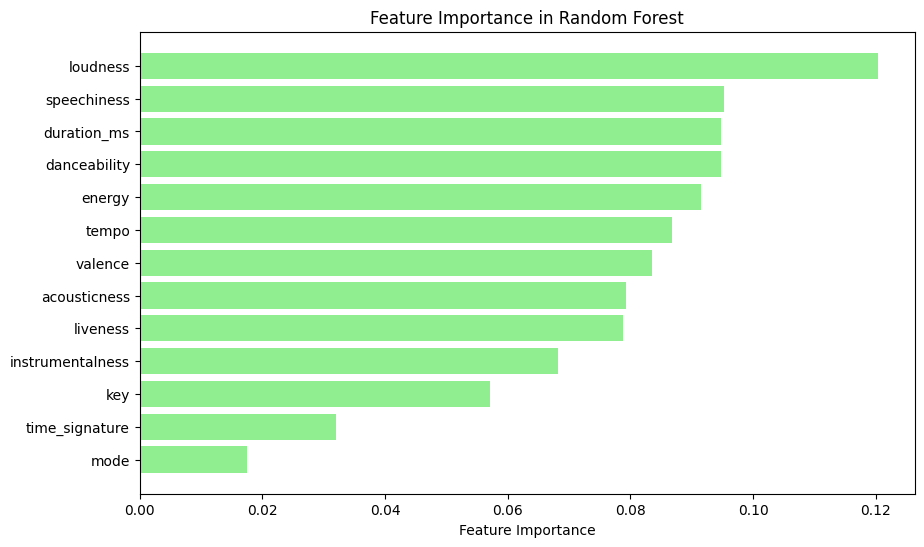

In [ ]:
importance_dict = best_rf_model.featureImportances

# Convert the feature importance vector into a dictionary mapping feature names to their importance values
mapped_importance = {features[i]: importance_dict[i] for i in range(len(features))}

# Convert the dictionary into lists for plotting
features_list = list(mapped_importance.keys())
importance_list = list(mapped_importance.values())

# Sort features by importance value in descending order
sorted_features = sorted(mapped_importance.items(), key=lambda x: x[1], reverse=True)

# Split the sorted list into two separate lists for plotting
features_list = [x[0] for x in sorted_features]
importance_list = [x[1] for x in sorted_features]

# Plot the feature importance chart
plt.figure(figsize=(10, 6))
plt.barh(features_list, importance_list, color='lightgreen')
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest')
plt.gca().invert_yaxis()
plt.show()

#### 1.5 Remarks:
- Given that the model achieves an accuracy above 80%, the predictive factors it relies on can be considered trustworthy for explaining song popularity.
- Key influential features include loudness, speechiness (the proportion of vocal or spoken components), duration, danceability, and energy.
- Conversely, features such as time_signature, mode, and key appear to be more individual characteristics and have limited effect on overall popularity._

### 2. XGBoost


#### 2.1 Init model

In [ ]:
xgb = SparkXGBRegressor(
    features_col="features",
    label_col="popularity",
    prediction_col="prediction",
    objective="reg:squarederror",
    num_workers=4,
    seed=16
)

evaluator = RegressionEvaluator(
    labelCol="popularity",
    predictionCol="prediction",
    metricName="rmse"
)

paramGrid = (ParamGridBuilder()
    .addGrid(xgb.max_depth, [10])
    .addGrid(xgb.learning_rate, [0.15, 0.17, 0.2])
    .addGrid(xgb.n_estimators, [300, 320, 350, 370, 400])
    .addGrid(xgb.subsample, [1.0])
    .addGrid(xgb.colsample_bytree, [0.5, 0.6])
    .build())

# TrainValidationSplit
tvs_xg = TrainValidationSplit(
    estimator=xgb,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    trainRatio=0.75,
    seed=16
)

# Choose the best model base on validation
tvs_model = tvs_xg.fit(train_data)
best_xgb_model = tvs_model.bestModel


2025-10-16 10:59:10,412 INFO XGBoost-PySpark: _fit Running xgboost-3.0.5 on 4 workers with
	booster params: {'colsample_bytree': 0.5, 'device': 'cpu', 'learning_rate': 0.15, 'max_depth': 10, 'objective': 'reg:squarederror', 'subsample': 1.0, 'seed': 16, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 300}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
[10:59:15] [0]	training-rmse:15.02113                               (0 + 4) / 4]
[10:59:15] [1]	training-rmse:14.19904
[10:59:15] [2]	training-rmse:13.35767
[10:59:15] [3]	training-rmse:12.58337
[10:59:15] [4]	training-rmse:12.06150
[10:59:15] [5]	training-rmse:11.62912
[10:59:15] [6]	training-rmse:11.27772
[10:59:15] [7]	training-rmse:10.89519
[10:59:15] [8]	training-rmse:10.60956
[10:59:15] [9]	training-rmse:10.38176
[10:59:15] [10]	training-rmse:10.22510
[10:59:15] [11]	training-rmse:10.02903
[10:59:15] [12]	training-rmse:9.79701
[10:59:15] [13]	training-rmse:9.65334
[10:59:15] [14]	training-rmse:9.5

In [ ]:
# Get all parameter name in XGBoost
param_names = set()
for param_map in paramGrid:
    for param in param_map:
        param_names.add(param.name)

# Take the best model, get all parameter and filter the used one
best_params = {}
for param_name in param_names:
    try:
        # Get Param obj by name
        param_obj = next(p for p in best_xgb_model.params if p.name == param_name)
        value = best_xgb_model.getOrDefault(param_obj)
        best_params[param_name] = value
    except StopIteration:
        best_params[param_name] = None
    except KeyError:
        best_params[param_name] = None

print("Best tuned Params:")
print(best_params)

# Test Evaluator
test_predictions = best_xgb_model.transform(test_data)
evaluator_rmse = RegressionEvaluator(labelCol="popularity", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="popularity", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="popularity", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(test_predictions)
mae = evaluator_mae.evaluate(test_predictions)
r2 = evaluator_r2.evaluate(test_predictions)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R^2: {r2}")

Best tuned Params:
{'colsample_bytree': 0.6, 'n_estimators': 320, 'subsample': 1.0, 'max_depth': 10, 'learning_rate': 0.2}


RMSE: 6.919099534712618
MAE: 3.2774398626078742
R^2: 0.8112247212386894


#### 2.2 Experimental Logbook

<table>
    <tr>
        <td rowspan = "2">Model</td>
        <td rowspan = "2">Evaluation Method</td>
        <td rowspan = "2">Data Split</td>
        <td colspan="6">Model Parameters</td>
        <td colspan="9">Model Results</td>
        <td rowspan = "2">Purpose</td>
    </tr>
    <tr>
        <td>maxDepth</td>
        <td>Learning rate</td>
        <td>n_estimators</td>
        <td>subsample</td>
        <td>colsample_bytree</td>
        <td>order</td>
        <td>maxDepth</td>
        <td>Learning rate</td>
        <td>n_estimators</td>
        <td>subsample</td>
        <td>colsample_bytree</td>
        <td>Order</td>
        <td>RMSE</td>
        <td>MAE</td>
        <td>R2</td>
    </tr>
    <tr>
        <td rowspan="5">RandomForestRegressor(featuresCol=&quot;&quot;features&quot;&quot;, labelCol=&quot;&quot;popularity&quot;&quot;)</td>
        <td>RMSE</td>
        <td>75%</td>
        <td>[4, 6, 8, 10]</td>
        <td>[0.05, 0.1, 0.2]</td>
        <td>[100, 200]</td>
        <td>[0.7, 0.8, 1.0]</td>
        <td>[0.7, 0.8, 1.0]</td>
        <td>default</td>
        <td>10</td>
        <td>0.2</td>
        <td>200</td>
        <td>1</td>
        <td>0.7</td>
        <td>default</td>
        <td>6.951206274</td>
        <td>3.30513078</td>
        <td>0.809468706</td>
        <td>Identify promising parameter ranges</td>
    </tr>
    <tr>
        <td>RMSE</td>
        <td>75%</td>
        <td>[8, 9, 10, 11]</td>
        <td>[0.1, 0.15, 0.2]</td>
        <td>[200, 250, 300]</td>
        <td>[0.8, 0.9, 1.0]</td>
        <td>[0.6, 0.7, 0.8]</td>
        <td>default</td>
        <td>10</td>
        <td>0.2</td>
        <td>300</td>
        <td>1</td>
        <td>0.6</td>
        <td>default</td>
        <td>6.920309571</td>
        <td>3.279458424</td>
        <td>0.811158688</td>
        <td>Fine-tune around the previously best results</td>
    </tr>
    <tr>
        <td>RMSE</td>
        <td>75%</td>
        <td>10</td>
        <td>0.2</td>
        <td>300</td>
        <td>1</td>
        <td>0.6</td>
        <td>gamma [0, 0.1, 0.3]<br>reg_alpha [0, 0.5, 1]<br>reg_lambda, [1, 3, 5])</td>
        <td>10</td>
        <td>0.2</td>
        <td>300</td>
        <td>1</td>
        <td>0.6</td>
        <td>gamma [0]<br>reg_alpha [0]<br>reg_lambda [1] (default)</td>
        <td>6.920309571</td>
        <td>3.279458424</td>
        <td>0.811158688</td>
        <td>With the optimal configuration, experiment with other related parameters</td>
    </tr>
    <tr>
        <td>RMSE</td>
        <td>75%</td>
        <td>10</td>
        <td>[0.2, 0.25, 0.3]</td>
        <td>[300, 350, 400]</td>
        <td>1</td>
        <td>[0.5, 0.6]</td>
        <td>default</td>
        <td>10</td>
        <td>0.2</td>
        <td>350</td>
        <td>1</td>
        <td>0.6</td>
        <td>default</td>
        <td>6.918233254</td>
        <td>3.275530661</td>
        <td>0.811271988</td>
        <td>If parameter setups such as alpha, etc. are ineffective, return to explore nearby regions with longer training focus</td>
    </tr>
    <tr>
        <td>RMSE</td>
        <td>75%</td>
        <td>10</td>
        <td>[0.15, 0.17, 0.2]</td>
        <td>[300, 320, 350, 370, 400]</td>
        <td>1</td>
        <td>[0.5, 0.6]</td>
        <td>default</td>
        <td>10</td>
        <td>0.2</td>
        <td>320</td>
        <td>1</td>
        <td>0.6</td>
        <td>default</td>
        <td>6.919099535</td>
        <td>3.277439863</td>
        <td>0.811224721</td>
        <td>Experiment with learning rates and n_estimators near the optimal values</td>
    </tr>
    <tr>
        <td colspan="15">Stopping criterion: further optimization yields negligible improvement — the model is considered saturated with the best accuracy around ~81.13% (R²)</td>
        <td>6.918233254</td>
        <td>3.275530661</td>
        <td>0.811271988</td>
    </tr>
</table>

#### 2.3 Remarks:
- The model achieved slightly better average performance compared to Random Forest (around 80.12%).
- The model can effectively explain the relationship between the features and popularity.

#### 2.4 Feature Importance

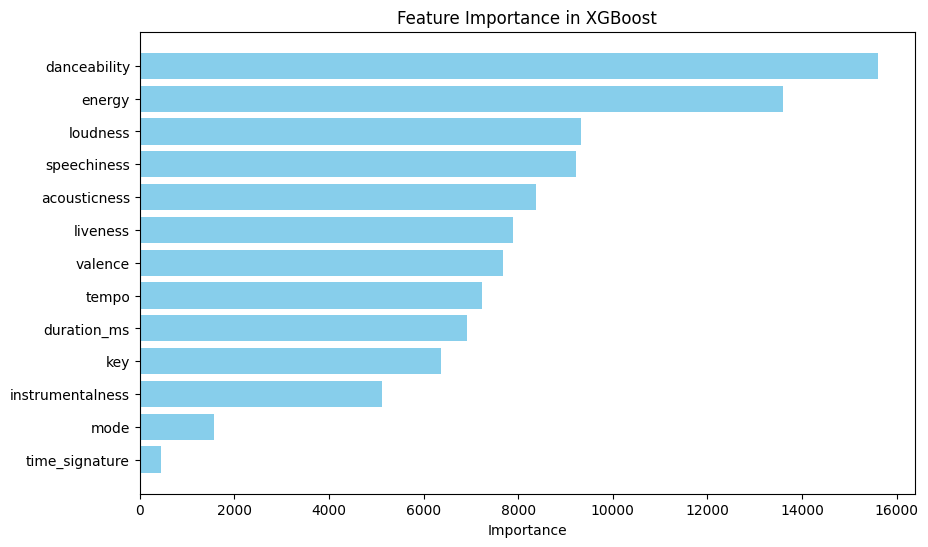

In [ ]:

booster = best_xgb_model.get_booster()
importance_dict = booster.get_score(importance_type='weight')

# Convert the feature importance vector into a dictionary mapping feature names to their importance values
mapped_importance = {}
for i, (k, v) in enumerate(importance_dict.items()):
    feature_name = features[i] if i < len(features) else f'feature_{i}'
    mapped_importance[feature_name] = v

# Convert the dictionary into lists for plotting
features_list = list(mapped_importance.keys())
importance_list = list(mapped_importance.values())

# Sort features by importance value in descending order
sorted_indices = np.argsort(importance_list)[::-1]

# Split the sorted list into two separate lists for plotting
features_list = [features_list[i] for i in sorted_indices]
importance_list = [importance_list[i] for i in sorted_indices]

# Plot the feature importance chart
plt.figure(figsize=(10, 6))
plt.barh(features_list, importance_list, color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance in XGBoost')
plt.gca().invert_yaxis()
plt.show()


#### 2.5 Remarks:
- This model has the highest reliability in analyzing the relationship between features and popularity.
- Several factors significantly influence popularity, such as Danceability, Energy, Loudness, and Speechiness.
- The factors identified by XGBoost are almost identical to those found by Random Forest, differing mainly in their relative importance
- There are still some personal or less influential factors that do not affect a song’s popularity, such as Time Signature and Mode.

### 3. Compare Random Forest and XGBoost


<table>
  <tr>
    <th></th>
    <th>Random Forest</th>
    <th>XGBoost</th>
  </tr>

  <tr>
    <td><b>Accuracy</b></td>
    <td>
      RMSE: 6.98173307178042<br>
      RMAE: 3.3063056533379<br>
      R2: 0.807791563834355
    </td>
    <td>
      RMSE: 6.9182325441787<br>
      RMAE: 3.27553066109784<br>
      R2: 0.811271988102267
    </td>
  </tr>

  <tr>
    <td><b>Feature-based Prediction</b></td>
    <td colspan="2">
      The two models evaluate feature importance differently. However, they share several highly influential attributes that largely determine song popularity, such as <i>Danceability, Energy, Loudness, and Speechiness</i>.
    </td>
  </tr>

  <tr>
    <td><b>Model Parameters</b></td>
    <td>
      d = 70, t = 30<br>
      node per tree = 2^d - 1<br>
      params = 70 * (2^31 - 1)<br>
      Computations = 2100 * n
    </td>
    <td>
      d = 350, t = 10<br>
      node per tree = 2^11 - 1<br>
      params = 350 * (2^11 - 1)<br>
      Computations = 3500 * n
    </td>
  </tr>

  <tr>
    <td><b>Computation Optimization</b></td>
    <td>
      Execution language: Scala / Java (JVM)<br> 
      Traverses all feature values or uses aggregation → multiple Spark stages.<br> 
      Parallelism: via threads or data partitions (no multithreading inside executor).<br> 
      Node synchronization: Spark Shuffle (high I/O overhead).<br> 
      Memory optimization: weak, due to distributed Java objects.<br> 
      Large number of trees and deep depth → training time increases linearly.
    </td>
    <td>
      Execution language: Native C++ (via XGBoost4J-Spark).<br> 
      Split mechanism: Histogram-based, much faster.<br> 
      Parallelism: OpenMP multithreading.<br> 
      Node synchronization: AllReduce (Rabit/NCCL), more efficient than Spark Shuffle.<br> 
      Memory optimization: Continuous C-style array storage.<br> 
      GPU support → significantly faster (gradient-based boosting).
    </td>
  </tr>

  <tr>
    <td><b>Computation Time</b><br><i>*note: not all runs were recorded*</i></td>
    <td>
      Average 30–40 minutes for optimal parameters across 4 models.<br>
      → About 10–15 minutes per model.
    </td>
    <td>
      Average 4 minutes for a good parameter set among top 30 models.<br> 
      → About 8–10 seconds per model.
    </td>
  </tr>

  <tr>
    <td><b>System Requirements</b></td>
    <td>
      Requires workers with large RAM and good network bandwidth for shuffling large trees.
    </td>
    <td>
      Requires computation libraries (numpy, pandas, xgboost, scikit-learn).<br> 
      Workers need stronger CPUs and preferably GPU support.
    </td>
  </tr>

  <tr>
    <td><b>Conclusion</b></td>
    <td>
      Does not require many installed libraries on workers, but slower computation, higher cost, and less scalability when the number of trees increases.<br> 
      → Suitable for medium configurations and easy deployment.
    </td>
    <td>
      High performance, fully utilizing multithreading and GPU acceleration.<br> 
      However, more complex installation and higher hardware requirements.<br> 
      → The most effective model for this problem.
    </td>
  </tr>
</table>


# IV. Conclusion
- Analyzing the relationship between musical features and song popularity is a complex challenge due to the very low correlation between feature variables and popularity — with a maximum of only about |0.15|. The linear regression model fails to predict effectively because of the non-linear nature of the data and its uneven distribution.
- Instead, non-linear models such as Random Forest and XGBoost have demonstrated superior performance, achieving prediction accuracy above 80%, thereby uncovering hidden relationships between features and song popularity. XGBoost outperforms in both efficiency and training time, making it more suitable for practical applications.
- Both models clearly identify key musical factors that strongly influence song popularity, including danceability, energy, loudness, and speechiness. These insights provide valuable information for artists and music companies to focus on developing products that better align with audience preferences, optimizing success in the market.
- Therefore, adopting non-linear models delivers outstanding analytical performance while offering practical implications and actionable insights for individuals and organizations in the music industry.


# V. References
1. https://xgboost.readthedocs.io/en/latest/jvm/xgboost4j_spark_tutorial.html
2. https://dmlc.github.io/2016/03/14/xgboost4j-portable-distributed-xgboost-in-spark-flink-and-dataflow.html
3. https://spark.apache.org/docs/latest/mllib-decision-tree.html
4. https://www.techscience.com/cmc/v71n2/45760/html
5. https://aicandy.vn/thuat-toan-random-forest-giai-thich-chi-tiet-va-ung-dung/
6. https://funix.edu.vn/chia-se-kien-thuc/xgboost-ung-dung-cua-xgboost/
7. https://machinelearningcoban.com/tabml_book/ch_model/random_forest.html
8. https://tuyendung.vti.com.vn/vi-VN/Blog/BlogDetail/163
9. https://vtitech.vn/xgboost-bai-12-dieu-chinh-so-luong-va-kich-thuoc-cua-decision-tree/
10. https://spark.apache.org/docs/latest/ml-tuning.html
11. https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.LinearRegression.html#pyspark.ml.regression.LinearRegression
12. Quách Đình Hoàng. (2025). Lab 3 – Linear Regression. Internal teaching material, Faculty of Information Technology, Ho Chi Minh City University of Technology and Education.
13. Quách Đình Hoàng. (2025). Lab 4 – Classification and Regression. Internal teaching material, Faculty of Information Technology, Ho Chi Minh City University of Technology and Education.